# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. To control the complexity of a model, we "charge" the model for "buying" larger slope coefficients, that boosts the error. This penalty, added to MSE for each unit of coefficient, means that the more complex models a model is, the more expensive it is. Our MSE thus increases in proportion to the amount of coefficient we "purchase."
2. More complex models have lower bias, but higher variance, and this makes the expected loss higher. Regularization allows us to reduce model variance in a deliberate, controlled way. This forces the model to pick more predictive variables and reduce the size of coefficients, resulting in interpretable and more reliable models. 
3. LASSO sends coefficients to zero as $\alpha$ increases. It removes variables from the model, and selects a model specification for you. Ridge, however, smoothly shrinks all the coefficients towards zero, but it never removes a variable completely. The LASSO penalty ($\alpha$) has points of non-differentiability at 0, or "corners." The Ridge penalty ($\alpha$) is smooth at zero, and increases faster due to the inclusion of squared terms. Ridge typically performs better, while the LASSO provides more interpretable results. 
4. We typically scale variables for use in regularized regression by z-score normalizing them so they have a mean of 0 and a variance of 1. Changing variable scales makes it easier to compare your variables indirectly by considering which ones have the most explanatory power on the margin. Without this scaling, a large coefficient might just reflect a large-scale feature rather than importance, making it so the penalty, $\alpha$, treats all features fairly.
5. The penalty $\alpha$ is selected via cross-validation. Pick a grid of $\alpha$ values. For each $\alpha$ value, use k-fCV to a) pick the coefficients to minimize MSE(b) + $\alpha$|b| on the training folds and b) evaluate MSE(b) on the test folds and save the estimate. Then pick the mean/median value of MSE(b) for that $\alpha$. Finally, pick the $\alpha$ that the mean/median value of MSE(b) across the grid. 
6. No. When conducting cross validation, you do not include the penalty term in evaluating the cross validated MSE. This is because The penalty affects the training of the model, not the performance on unseen data. Cross validation is meant to estimate out-of-sample prediction error, so we focus on actual errors, not the regularization cost. 

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [314]:
import numpy as np 
import pandas as pd
from sklearn.linear_model import LassoCV, lasso_path, LinearRegression, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import matplotlib.pyplot as plt 
import seaborn as sns

In [315]:
#1
df = pd.read_csv('cars_hw.csv')
df['Age'] = 2026 - df['Make_Year']
df_raw = df[['Mileage_Run', 'Age']].values
y = df['Price'].values

poly = PolynomialFeatures(degree=3, include_bias=False)
df_poly = poly.fit_transform(df_raw)
poly_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_poly)

In [316]:
#2
lr = LinearRegression()
lr.fit(df_scaled, y)
 
coef_lr = pd.Series(lr.coef_, index=poly_names)
print("\nLinear Regression Coefficients:")
print(coef_lr.to_string())
 
interaction_coef = coef_lr["Mileage_Run Age"]
print(f"\nMileage_Run x Age interaction coefficient: {interaction_coef:.4f}")
print(f"Sign: {'Positive (+)' if interaction_coef > 0 else 'Negative (-)'}")


Linear Regression Coefficients:
Mileage_Run          9.117748e+05
Age                 -2.481722e+05
Mileage_Run^2       -2.072926e+05
Mileage_Run Age     -1.671212e+06
Age^2                3.505507e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    3.388195e+05
Mileage_Run Age^2    7.167816e+05
Age^3               -2.100379e+05

Mileage_Run x Age interaction coefficient: -1671212.3564
Sign: Negative (-)


In [317]:
#3
alpha_grid = np.logspace(1,3,20)
model = LassoCV(cv = 20, alphas=alpha_grid, random_state=10, max_iter=100_000)
model = model.fit(df_scaled,y) 
coefs = model.coef_ 

print(coefs[:5])
var_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

[  779076.20465096  -133953.43126018  -201563.40852792 -1322418.84628094
        0.        ]


/var/folders/3j/kl8rc94d48ggmgy06v1w358r0000gn/T/ipykernel_23840/2977242556.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


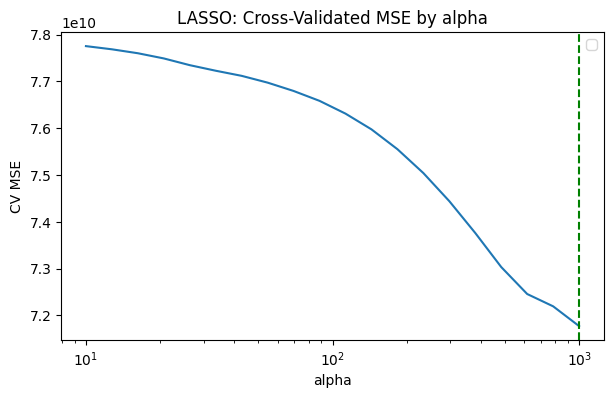

Optimal cost hyperparameter: 1000.0


In [318]:
#4
index_star = np.argmin( np.median(model.mse_path_,axis=1) )
alpha_star = model.alphas_[index_star]

plt.figure(figsize=(7, 4))
sns.lineplot(x = model.alphas_, y = np.median(model.mse_path_,axis=1))
plt.axvline(x=alpha_star, color='green', linestyle='--', linewidth=1.5)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('CV MSE')
plt.title('LASSO: Cross-Validated MSE by alpha')
plt.legend()
plt.show()
print(f'Optimal cost hyperparameter: {alpha_star}')

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.405e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.677e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

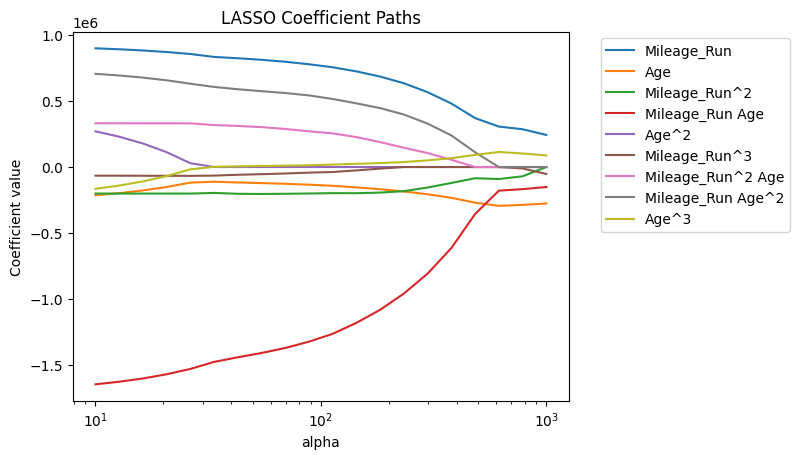

In [319]:
#5
alpha_grid = np.logspace(1,3,20)
coefs = []
for alpha in alpha_grid: 
    model = Lasso(alpha=alpha, max_iter=10_000)
    model = model.fit(df_scaled,y) 
    coefs.append(model.coef_) 
coefs = np.array(coefs) 

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i], label=var_names[i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [320]:
#6
lasso_best = Lasso(alpha=alpha_star, max_iter=10_000)
lasso_best.fit(df_scaled, y)

lasso_coef_df = pd.Series(lasso_best.coef_, index=var_names)
selected   = lasso_coef_df[lasso_coef_df != 0]
zeroed_out = lasso_coef_df[lasso_coef_df == 0]

print("Feature Selection at Optimal Alpha:")
print(f"Total features  : {len(var_names)}")
print(f"Selected (≠ 0)  : {len(selected)}")
print(f"Zeroed out (= 0): {len(zeroed_out)}  ({len(zeroed_out)/len(var_names)*100}%)")
print("\nSelected features:\n", selected.to_string())
print("\nZeroed-out features:\n", zeroed_out.index.tolist())

Feature Selection at Optimal Alpha:
Total features  : 9
Selected (≠ 0)  : 5
Zeroed out (= 0): 4  (44.44444444444444%)

Selected features:
 Mileage_Run        242953.216388
Age               -276500.895776
Mileage_Run Age   -151598.545767
Mileage_Run^3      -52410.347536
Age^3               87796.740706

Zeroed-out features:
 ['Mileage_Run^2', 'Age^2', 'Mileage_Run^2 Age', 'Mileage_Run Age^2']


In [321]:
#7
comparison = pd.DataFrame({
    'Linear Regression': coef_lr,
    'LASSO':     lasso_coef_df
})
comparison['|LR|'] = comparison['Linear Regression'].abs()
comparison['|LASSO|'] = comparison['LASSO'].abs()
comparison['Mag_Increase'] = comparison['|LASSO|'] > comparison['|LR|']
comparison['Sign_Change']  = np.sign(comparison['Linear Regression']) != np.sign(comparison['LASSO'])

print("Coefficient Comparison: Linear Regression vs LASSO:")
print(comparison[['Linear Regression', 'LASSO', 'Mag_Increase', 'Sign_Change']].to_string())

increased = comparison[comparison['Mag_Increase']]
sign_flip  = comparison[comparison['Sign_Change'] & (comparison['LASSO'] != 0)]

print(f"\nCoefficients that increased in magnitude from regression to LASSO: {len(increased)}")
if len(increased):
    print(increased[['Linear Regression', 'LASSO']].to_string())

print(f"\nCoefficients that changed sign: {len(sign_flip)}")
if len(sign_flip):
    print(sign_flip[['Linear Regression', 'LASSO']].to_string())

Coefficient Comparison: Linear Regression vs LASSO:
                   Linear Regression          LASSO  Mag_Increase  Sign_Change
Mileage_Run             9.117748e+05  242953.216388         False        False
Age                    -2.481722e+05 -276500.895776          True        False
Mileage_Run^2          -2.072926e+05      -0.000000         False         True
Mileage_Run Age        -1.671212e+06 -151598.545767         False        False
Age^2                   3.505507e+05      -0.000000         False         True
Mileage_Run^3          -6.514490e+04  -52410.347536         False        False
Mileage_Run^2 Age       3.388195e+05      -0.000000         False         True
Mileage_Run Age^2       7.167816e+05      -0.000000         False         True
Age^3                  -2.100379e+05   87796.740706         False         True

Coefficients that increased in magnitude from regression to LASSO: 1
     Linear Regression          LASSO
Age     -248172.185538 -276500.895776

Coefficient

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [322]:
#1
X = pd.read_csv('heart_failure_clinical_records_dataset.csv')
X_raw = X[['age', 'ejection_fraction', 'serum_creatinine']].values

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_raw)
poly_names = poly.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

X_raw2 = X[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]
poly2 = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)
X_poly2 = poly2.fit_transform(X_raw2)
poly_names2 = poly2.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])
X_scaled2 = scaler.fit_transform(X_poly2)

X_full_scaled = np.concatenate([X_scaled, X_scaled2], axis=1)
X2 = np.concatenate([X_poly, X_poly2], axis = 1)
X_names = np.concatenate([poly_names, poly_names2])

In [323]:
#2
y = X['DEATH_EVENT'].values
model = LinearRegression()
model.fit(X_full_scaled, y)

coef_df = pd.Series(model.coef_, index=X_names)
print("\nLinear Regression Coefficients:")
print(coef_df.to_string())

# It appears counterintuitive that serum_creatinine and ejection_fraction have negative coefficients
# Elevated serum_creatinine is a strong predictor of heart failure death, so it should be positive
# A low ejection fraction is a defining feature of systolic heart failure and should positively predict death

# This occurs because OLS is splitting the true nonlinear effect across all polynomial terms and can't assign a coherent sign to any one of them individually

# For these counterintuitive variables, their relationship with mortality is likely nonlinear
# A polynomial expansion can better capture this effect
# LASSO will resolve sign confusion by zeroing out redundant polynomial terms & letting the surviving coefficients take on their directions


Linear Regression Coefficients:
age                                       1.549928
ejection_fraction                        -2.025371
serum_creatinine                         -0.739027
age^2                                    -3.547991
age ejection_fraction                    -0.861860
age serum_creatinine                      1.680570
ejection_fraction^2                       3.317931
ejection_fraction serum_creatinine        2.604767
serum_creatinine^2                       -2.703084
age^3                                     1.889040
age^2 ejection_fraction                   1.022027
age^2 serum_creatinine                   -0.672141
age ejection_fraction^2                   0.017577
age ejection_fraction serum_creatinine   -1.584620
age serum_creatinine^2                    1.433246
ejection_fraction^3                      -1.253594
ejection_fraction^2 serum_creatinine     -1.219271
ejection_fraction serum_creatinine^2      1.217335
serum_creatinine^3                       -0.01490

In [324]:
#3 
model = LassoCV(cv = 20, alphas=np.logspace(-5,5,30), random_state=10)
model = model.fit(X_full_scaled,y) 
coefs = model.coef_ 

print(coefs[:5])

[-0.         -0.32626025  0.11683572  0.         -0.        ]


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.730e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.332e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the numb

/var/folders/3j/kl8rc94d48ggmgy06v1w358r0000gn/T/ipykernel_23840/4167071740.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


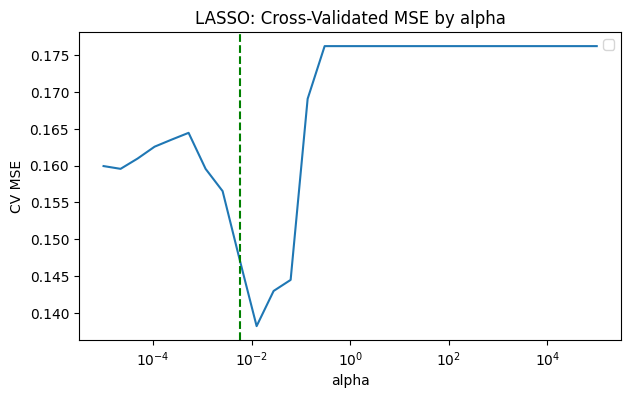

Optimal cost hyperparameter: 0.005736152510448681


In [325]:
#4
alpha_star = model.alpha_

plt.figure(figsize=(7, 4))
sns.lineplot(x = model.alphas_, y = np.median(model.mse_path_,axis=1))
plt.axvline(x=alpha_star, color='green', linestyle='--', linewidth=1.5)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('CV MSE')
plt.title('LASSO: Cross-Validated MSE by alpha')
plt.legend()
plt.show()
print(f'Optimal cost hyperparameter: {alpha_star}')

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.881e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.635e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

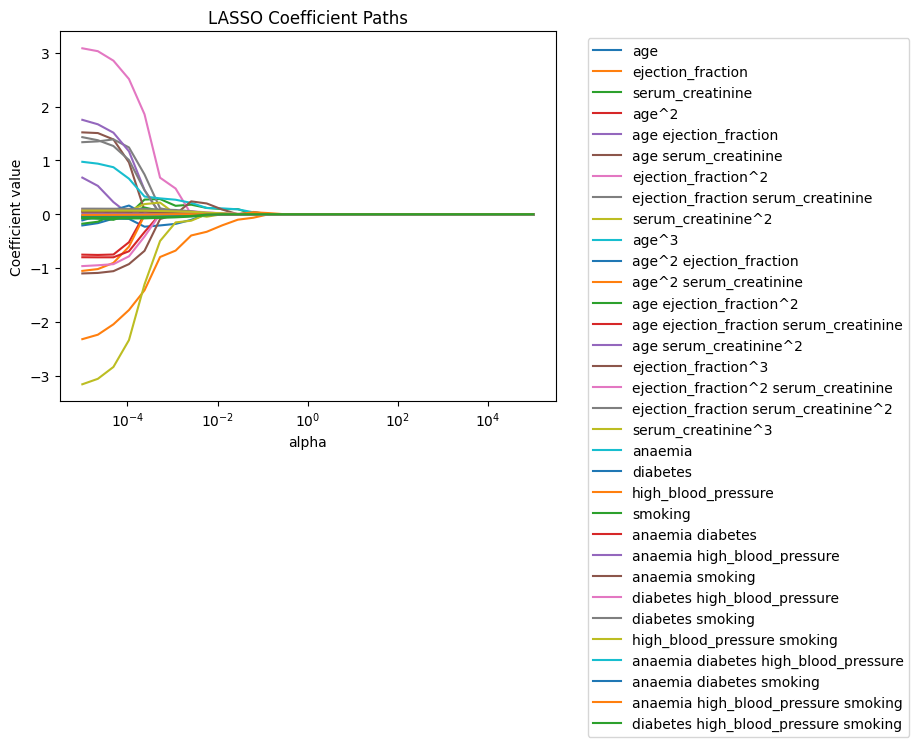

In [326]:
#5
alpha_grid = np.logspace(-5,5,30)
coefs = []
for alpha in alpha_grid: 
    m = Lasso(alpha=alpha, max_iter=10_000)
    m = m.fit(X_full_scaled,y) 
    coefs.append(m.coef_) 
coefs = np.array(coefs) 

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i], label=X_names[i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [327]:
#6
lr = LinearRegression()
lr.fit(X_full_scaled, y)
coef_df = pd.Series(lr.coef_, index=X_names)

lasso_best = Lasso(alpha=alpha_star, max_iter=10_000)
lasso_best.fit(X_full_scaled, y)

lasso_coef_df = pd.Series(lasso_best.coef_, index=X_names)
selected = lasso_coef_df[lasso_coef_df != 0]
zeroed_out = lasso_coef_df[lasso_coef_df == 0]

selected    = lasso_coef_df[lasso_coef_df != 0]
zeroed_out  = lasso_coef_df[lasso_coef_df == 0]

print(f"Total features  : {len(X_names)}")
print(f"Selected (≠ 0)  : {len(selected)}")
print(f"Zeroed out (= 0): {len(zeroed_out)}  ({len(zeroed_out)/len(X_names)*100:.1f}%)")
print("\nSelected features:\n", selected.to_string())

comparison = pd.DataFrame({
    'Linear Regression': coef_df,
    'LASSO': lasso_coef_df
})

comparison['|LR|']  = comparison['Linear Regression'].abs()
comparison['|LASSO|'] = comparison['LASSO'].abs()
comparison['Mag_Increase'] = comparison['|LASSO|'] > comparison['|LR|']

nonzero_mask = ~np.isclose(comparison['LASSO'], 0)
comparison['Sign_Change'] = (np.sign(comparison['Linear Regression']) != np.sign(comparison['LASSO'])) & nonzero_mask

print("Coefficient Comparison: Linear Regression vs LASSO:")
print(comparison[['Linear Regression', 'LASSO', 'Mag_Increase', 'Sign_Change']].to_string())

Total features  : 33
Selected (≠ 0)  : 13
Zeroed out (= 0): 20  (60.6%)

Selected features:
 ejection_fraction                      -0.326260
serum_creatinine                        0.116836
age^3                                   0.116097
ejection_fraction^3                     0.200132
ejection_fraction^2 serum_creatinine    0.035397
serum_creatinine^3                     -0.045957
anaemia                                 0.013051
smoking                                -0.020900
diabetes high_blood_pressure            0.026322
diabetes smoking                        0.020528
high_blood_pressure smoking             0.028936
anaemia diabetes smoking               -0.000207
diabetes high_blood_pressure smoking   -0.006543
Coefficient Comparison: Linear Regression vs LASSO:
                                        Linear Regression     LASSO  Mag_Increase  Sign_Change
age                                              1.549928 -0.000000         False        False
ejection_fraction           

Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

Very few coefficients increase in magnitude from linear regression to LASSO, only serum_creatinine^3. However, there are a few sign changes for non-zero coefficients. 

Only serum_creatinine^3 increasing makes sense because this multicollinearity. Once all the correlated serum_creatinine polynomial terms are zeroed out, the cubic term absorbs the full effect and grows.

The few sign changes make sense too. Serum creatinine flips to positive, correctly reflects that high creatinine predicts death. Same with ejection_fraction^3, ejection_fraction^2 serum_creatinine, and anaemia. 

For these reasons, LASSO seems to make much more sense. 

OLS has zero bias by construction but enormous variance. With 33 correlated polynomial features and only 299 observations, it is overfitting. LASSO accepts a small amount of bias (shrinking coefficients toward zero) in exchange for dramatically lower variance, producing a sparser, more stable model whose signs are actually interpretable. The 4 sign flips are not random they are corrections of multicollinearity-induced distortions.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

#1
The objective function for this problem is MSE + $\alpha (b_1)^2$, so it is $\frac{1}{n} \sum_{i=1}^n (\tilde{y}_i - b_0 + b_1\tilde{x}_i)^2 + \alpha b_1^2$

#2
derivative with respect to $b_0$:
$-2 \sum_{i=1}^n (\tilde{y}_i - b_0 + b_1\tilde{x}_i) = 0$
$\sum_{i=1}^n (\tilde{y}_i - b_0 + b_1\tilde{x}_i) = 0$
Since $\tilde{y}_i$ and $\tilde{x}_i$ are mean centered, the whole equation simplifies to $b_0$ = 0

derivative with respect to $b_1$:
$-2 \sum_{i=1}^n \tilde{x}_i(\tilde{y}_i - b_1\tilde{x}_i) + 2\alpha b_1 = 0$
$\sum_{i=1}^n \tilde{x}_i(\tilde{y}_i - b_1\tilde{x}_i) + \alpha b_1 = 0$
$\sum_{i=1}^n \tilde{x}_i\tilde{y}_i - b_1 \sum_{i=1}^n \tilde{x}^2_i - \alpha b_1= 0$
$\sum_{i=1}^n \tilde{x}_i\tilde{y}_i = b_1 (\sum_{i=1}^n \tilde{x}_i^2 + \alpha)$
$b_1 = \frac{\sum_{i=1}^n \tilde{x}_i\tilde{y}_i}{\sum_{i=1}^n \tilde{x}_i^2 + \alpha}$

#3
Increasing $\alpha$ makes the slope coefficient decrease toward zero because it is in the denominator of $b_1$. This makes sense because ridge penalizes large coefficients, so it shrinks the slope as $\alpha$ increases.

#4 
If you instead use the LASSO penalty of +$\alpha|b_1|$, we run into the challenge that the absolute value $|b_1|$ is not differentiable at 0. For this reason, you cannot take a derivative and solve algebraically like we did for ridge. 

If we set 
S = $\sum_{i=1}^n \tilde{x}_i\tilde{y}_i$ 
X = $\sum_{i=1}^n \tilde{x}_i^2$ 

and ignore the non-differentiability for $b_1 \neq$ 0, the derivative is:
$-2S + 2Xb_1 + \alpha$ +/- $b_1$ = 0
$ S = Xb_1 + \frac{\alpha}{2}$ +/- $b_1$ 

This gives us a piecewise solution:
for S > $\frac{\alpha}{2}$, $b_1$ = $\frac{S - \alpha /2}{X}$
for S < $-\frac{\alpha}{2}$, $b_1$ = $\frac{S + \alpha /2}{X}$
for |S| ≤ $-\frac{\alpha}{2}$, $b_1$ = 0